In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lammps import lammps

sys.path.insert(0, '..')
from src import *

# Set number of OpenMP threads
os.environ['OMP_NUM_THREADS'] = '10'

In [3]:
def cell_is_undeformed(lmp):
    cm = get_cell_matrix(lmp)
    return np.all(cm == cm[0,0] * np.eye(3))

I = np.eye(3)

# Compare the time-averages

In [4]:
rho = 1.058
L = 10
epsilon = 1.0  # LJ energy scale
sigma = 1.0    # LJ length scale
offset = 0.05  # to avoid creating atoms on simbox face

T = 3.0
time_step = 0.0005
thermo_tau = 100 * time_step
#baro_tau = 1000 * time_step

equil_temp_steps = 5_000 
# equil_press_steps = 10_000
prod_steps = 1000
save_every = 10

In [5]:
savedir = f"../data/test/test_T{T}"
os.makedirs(savedir, exist_ok=True)
print(savedir)

../data/test/test_T3.0


In [6]:
lmp = lammps(cmdargs=['-log', os.path.join(savedir,'sim.log'), '-sf', 'omp',
                     "-screen", "none", "-nocite"])

In [7]:
lmp.commands_string(f"""
units lj
dimension 3
boundary p p p
atom_style atomic

lattice fcc {rho} origin {offset} {offset} {offset}
region simbox block 0 {L} 0 {L} 0 {L} units lattice
create_box 1 simbox
create_atoms 1 box
mass 1 1.0
velocity all create {T} 94673 mom yes

pair_style lj/smooth 2.5 3.5
pair_coeff 1 1 1.0 1.0
pair_modify shift yes

compute temp all temp

variable time equal time
variable etot equal etotal
variable vol equal vol
variable dens equal density

compute press all pressure thermo_temp
compute press_pot all pressure NULL virial
compute born_matrix all born/matrix numdiff 1.0e-6 press_pot
compute born_matrix_nl all born/matrix/nonlinear 1.0e-6 press_pot born_matrix

# Screen and log output
thermo 1000
thermo_style custom step temp press density vol etotal
thermo_modify flush yes

# Timestep (default 0.005 for lennard-jones)
timestep {time_step}

fix nvt_eq all nvt temp {T} {T} {thermo_tau}
run {equil_temp_steps}
unfix nvt_eq

fix nve_prod all nve
fix press_output all ave/time 1 1 {save_every} &
   v_time c_press[*] file "{savedir}/press.dat"
fix press_pot_output all ave/time 1 1 {save_every} &
   v_time c_press_pot[*] file "{savedir}/press_pot.dat"
fix born_output all ave/time 1 1 {save_every} &
   v_time c_born_matrix[*] file "{savedir}/born.dat"
fix born_nl_output all ave/time 1 1 {save_every} &
   v_time c_born_matrix_nl[*] file "{savedir}/born_nl.dat"
fix thermo_output all ave/time 1 1 {save_every} &
   v_time c_thermo_temp v_etot v_vol v_dens file "{savedir}/thermo.dat"
""")

Timing for 1000 steps writing values every 10 steps:
| task | time |
|------|------|
| lammps run w/o born/matrix/nonlinear computation | 6.8 s |
| born/matrix/nonlinear computed and saved by lammps | 56 s |
| nonlinear born computed manually | 2 min 33 s |

In [90]:
#%%time
#lmp.command("run 1000")

CPU times: user 1min 19s, sys: 544 ms, total: 1min 20s
Wall time: 6.76 s


In [8]:
def get_pk2_pot(lmp, cell_matrix_ref, F, eps=1e-7):
    set_cell_matrix(lmp, F@cell_matrix_ref, remap=True, convert=True)
    F_inv = np.linalg.inv(F)
    sigma = -lammps_array_to_matrix(lmp.numpy.extract_compute("press_pot", 0, 1))
    return np.linalg.det(F) * F_inv @ sigma @ F_inv.T

def compute_F_deform(E):
    return np.linalg.cholesky(I + 2*E, upper=True)

def compute_born_nonlin_pk2_der(lmp, cell_matrix=None, eps=1e-6, undeform=True):
    E_deforms, map_ij = probe_deformations_sym(eps)
    
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if cell_matrix is None else cell_matrix
    NB = np.zeros((3,)*6)
    
    for (k,l), dE1 in zip(map_ij, E_deforms):
        for (m,n), dE2 in zip(map_ij, E_deforms):
            S11 = get_pk2_pot(lmp, h0, compute_F_deform(- dE1 - dE2))
            S12 = get_pk2_pot(lmp, h0, compute_F_deform(- dE1 + dE2))
            S21 = get_pk2_pot(lmp, h0, compute_F_deform(+ dE1 - dE2))
            S22 = get_pk2_pot(lmp, h0, compute_F_deform(+ dE1 + dE2))
            NB[:,:,k,l,m,n] = (S22 + S11 - S12 - S21) / (4 * eps**2)
            if m != n:
                NB[:, :, k, l, n, m] = NB[:, :, k, l, m, n]
        if k != l:
            NB[:, :, l, k] = NB[:, :, k, l]
    for (i,j) in map_ij[2:]:
        NB[j,i] = NB[i,j]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return NB

In [9]:
get_cell_matrix(lmp)

array([[15.578469,  0.      ,  0.      ],
       [ 0.      , 15.578469,  0.      ],
       [ 0.      ,  0.      , 15.578469]])

In [10]:
%%time
ntimes = prod_steps // save_every
NB_arr = np.zeros((ntimes,) + (3,)*6)

for i in range(ntimes):
    NB_arr[i] = compute_born_nonlin_pk2_der(lmp, eps=1e-6, undeform=True)
    lmp.command(f"run {save_every}")

CPU times: user 16min 44s, sys: 6.1 s, total: 16min 50s
Wall time: 1min 24s


In [11]:
NB_avg = NB_arr.mean(axis=0)

In [12]:
born_nl_data = pd.read_csv(os.path.join(savedir, 'born_nl.dat'), sep=' ', header=None, 
                           names=['timestep', 'time']+['p'+str(i) for i in range(1,127)],
                           skiprows=2, index_col=False)

In [13]:
V = lmp.numpy.extract_variable("vol")
born_nl_raw = np.array(born_nl_data.iloc[:,2:])
born_nl_voigt = lammps_array_to_matrix(born_nl_raw.reshape(len(born_nl_raw), 21, 6).swapaxes(-1, -2))
born_nl_arr = voigt_to_tensor(born_nl_voigt, order=3) / V

In [14]:
born_nl_avg = born_nl_arr.mean(axis=0)

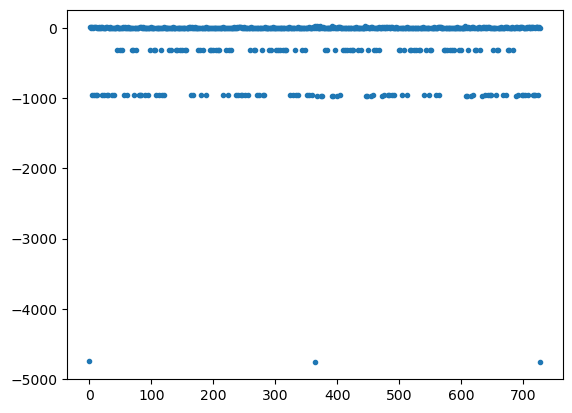

In [15]:
plt.plot(born_nl_avg.flatten(), '.')

In [16]:
np.linalg.norm(NB_avg - born_nl_avg) / np.linalg.norm(NB_avg)

np.float64(0.0002899306946382349)

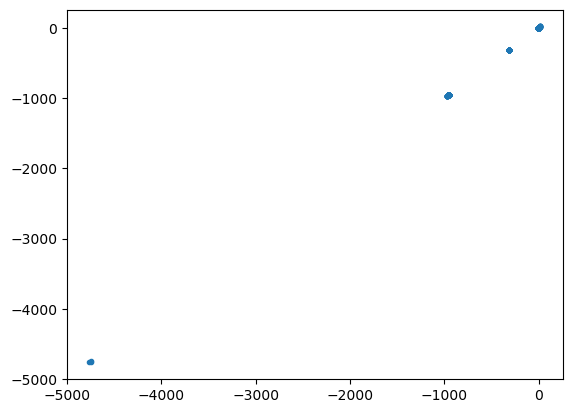

In [17]:
plt.plot(NB_avg.flatten(), born_nl_avg.flatten(), '.')